# Data featuring

## Imports

In [4]:
# packages
import pandas as pd
pd.set_option("display.max_columns", 100)

import numpy as np

# graphs
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["font.size"] = 14

import seaborn as sns

# stats
import scipy.stats as spstats

# package perso
from titanic.eda import stats, describe_numeric
from titanic.data import load_processed_data

## Load data

In [5]:
df = load_processed_data("../data/processed/titanic_cleaned.parquet")

print(df.shape)
df.head()

(1309, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Features engineering

In [4]:
# test - à supprimer
from titanic.features import build_features
df = build_features(df)

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Surname,Title,HasNickname,SexIsMale,AgeGroup,AgeDecade,IsChild,IsAlone,HasFamily,FamilySize,TicketText,TicketNumber,TicketNumberClass,Deck,CabinNumber,CabinCount,SurnameValueCounts,FamilySizeValueCounts,CabinValueCounts,TicketValueCounts,FareValueCounts,FarePerTicketPassenger,FarePerTicketPassenger_log1p,GroupSize,GroupType,FarePerPerson,FarePerPerson_log1p,AgeETR
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr,0,1,young_adult,20-29,0,0,1,2,A5,21171,2,NaN,NaN,1.0,2,235,NaN,1,18,7.25000,2.110213,2,couple,3.625000,1.531476,22.0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs,1,0,adult,30-39,0,0,1,2,PC,17599,1,C,85.0,1.0,2,235,2.0,2,2,35.64165,3.601186,2,couple,35.641650,3.601186,38.0
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss,0,0,adult,20-29,0,1,0,1,STONO2,3101282,3,NaN,NaN,1.0,1,790,NaN,1,23,7.92500,2.188856,3,family,2.641667,1.292441,26.0
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs,1,0,adult,30-39,0,0,1,2,NaN,113803,1,C,123.0,1.0,2,235,2.0,2,6,26.55000,3.316003,2,couple,26.550000,3.316003,35.0
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr,0,1,adult,30-39,0,1,0,1,NaN,373450,3,NaN,NaN,1.0,2,790,NaN,1,61,8.05000,2.202765,1,single,8.050000,2.202765,35.0


### Surname - Nom de famille

In [6]:
from titanic.features import extract_surname
df["Surname"] = extract_surname(df)
display(stats(df).loc[["Surname"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Surname,str,1309,0 (0%),875,Andersson,11,/,/,/,/,/,/,/


In [7]:
df[["Name","Surname"]].sample(10, random_state=42)

,Name,Surname
1148,"Niklasson, Mr. Samuel",Niklasson
1049,"Borebank, Mr. John James",Borebank
982,"Pedersen, Mr. Olaf",Pedersen
808,"Meyer, Mr. August",Meyer
1195,"McCarthy, Miss. Catherine Katie""""",McCarthy
240,"Zabour, Miss. Thamine",Zabour
1118,"McNeill, Miss. Bridget",McNeill
596,"Leitch, Miss. Jessie Wills",Leitch
924,"Johnston, Mrs. Andrew G (Elizabeth Lily"" Watson)""",Johnston
65,"Moubarek, Master. Gerios",Moubarek


Cette variable permettrait surtout de retrouver le nom de famille des différentes personnes.

### Title

C’est une variable dérivée de la variable Name.

In [8]:
from titanic.features import extract_title
df["Title"] = extract_title(df)
display(stats(df).loc[["Title"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Title,str,1309,0 (0%),4,Mr,783,/,/,/,/,/,/,/


In [9]:
df[["Name","Title"]].sample(10, random_state=42)

,Name,Title
1148,"Niklasson, Mr. Samuel",Mr
1049,"Borebank, Mr. John James",Mr
982,"Pedersen, Mr. Olaf",Mr
808,"Meyer, Mr. August",Mr
1195,"McCarthy, Miss. Catherine Katie""""",Miss
240,"Zabour, Miss. Thamine",Miss
1118,"McNeill, Miss. Bridget",Miss
596,"Leitch, Miss. Jessie Wills",Miss
924,"Johnston, Mrs. Andrew G (Elizabeth Lily"" Watson)""",Mrs
65,"Moubarek, Master. Gerios",Master


In [10]:
df["Title"].value_counts()

Title
Mr        783
Miss      262
Mrs       203
Master     61
Name: count, dtype: int64

### Ticket

In [11]:
from titanic.features import split_ticket, extract_ticket_number_class
df["TicketText"], df["TicketNumber"] = zip(*df["Ticket"].map(split_ticket))
df["TicketNumber"] = (
    pd.to_numeric(df["TicketNumber"], errors="coerce")
    .fillna(-1)
    .astype(int)
)
df["TicketNumberClass"] = extract_ticket_number_class(df)

### FarePerPerson

In [12]:
from titanic.features import compute_family_size, count_values, compute_group_size, assign_group_type, compute_fare_per_ticket_passenger, compute_fare_per_person

# Family
df["FamilySize"] = compute_family_size(df)

# Counts
df["SurnameValueCounts"] = count_values(df, "Surname")
df["FamilySizeValueCounts"] = count_values(df, "FamilySize")
df["CabinValueCounts"] = count_values(df, "Cabin")
df["TicketValueCounts"] = count_values(df, "Ticket")
df["FareValueCounts"] = count_values(df, "Fare")

# Fare based on exact ticket count
df["FarePerTicketPassenger"] = compute_fare_per_ticket_passenger(df)
df["FarePerTicketPassenger_log1p"] = np.log1p(df["FarePerTicketPassenger"])

# Group
df["GroupSize"] = compute_group_size(df)
df["GroupType"] = assign_group_type(df)

# Fare based on inferred group size
df["FarePerPerson"] = compute_fare_per_person(df)
df["FarePerPerson_log1p"] = np.log1p(df["FarePerPerson"])

### Age - Benchmark des méthodes d'imputation de Age

- La variable `Age` présente environ 20 % de valeurs manquantes. Comme cette variable est potentiellement importante pour la prédiction de la survie, l'imputation ne doit pas être traitée comme une simple opération mécanique.  
- Pour comparer plusieurs stratégies, nous avons utilisé uniquement les passagers dont l'âge est connu, puis masqué artificiellement 20 % de ces âges. Chaque méthode d'imputation est ensuite évaluée sur sa capacité à retrouver les âges masqués.  
- La métrique principale utilisée est la MAE, qui mesure l'erreur moyenne en années.

On commence par réaliser un benchmark de différentes méthodes d’imputation.  
On choisira simplement celle qui a les meilleurs résultats, réalisé sur des variables en mode supervisé, c’est-à-dire pour lesquelles on connaît réellement les âges.

In [13]:
from titanic.imputations_age import benchmark_age_imputations

Avant de lancer le benchmark, il faut au minimum :
```python
df["Title"]
df["FarePerTicketPassenger"]
df["FarePerTicketPassenger_log1p"]
df["FarePerPerson"]
df["FarePerPerson_log1p"]
```

In [14]:
# variables candidates

age_features = [
    "Pclass",
    "Sex",
    "Title",
    "SibSp",
    "Parch",
    "FarePerTicketPassenger_log1p",
    "Embarked"
]

categorical_features = [
    "Sex",
    "Title",
    "Embarked"
]

C’est un bon mix :

- `Title` : probablement le plus important
- `Pclass` : statut social
- `FarePerTicketPassenger_log1p` : niveau économique
- `FarePerPerson_log1p` : niveau économique
- `SibSp`, Parch : structure familiale
- `Sex` : utile, même si partiellement capturé par Title
- `Embarked` : léger signal possible

In [15]:
age_benchmark_results = benchmark_age_imputations(
    df=df,
    features=age_features,
    categorical_features=categorical_features,
    mask_frac=0.2,
    random_state=42
)

age_benchmark_results
# regarder MAE : en moyenne, l’imputation se trompe d’environ x ans.

,MAE,RMSE,R2
IterativeExtraTrees,8.295632,11.082629,0.456913
ExtraTreesRegressor,8.302697,11.105542,0.454666
RandomForest,8.484777,11.131501,0.452113
Median_by_Title_Pclass,8.678612,11.352420,0.430150
LinearRegression,9.024419,11.351529,0.430240
KNNRegressor,9.270275,12.129120,0.349508
Median_by_Title,9.582919,12.529387,0.305866
KNNImputer,10.076506,13.162857,0.233903
Median,11.515933,15.065556,-0.003584


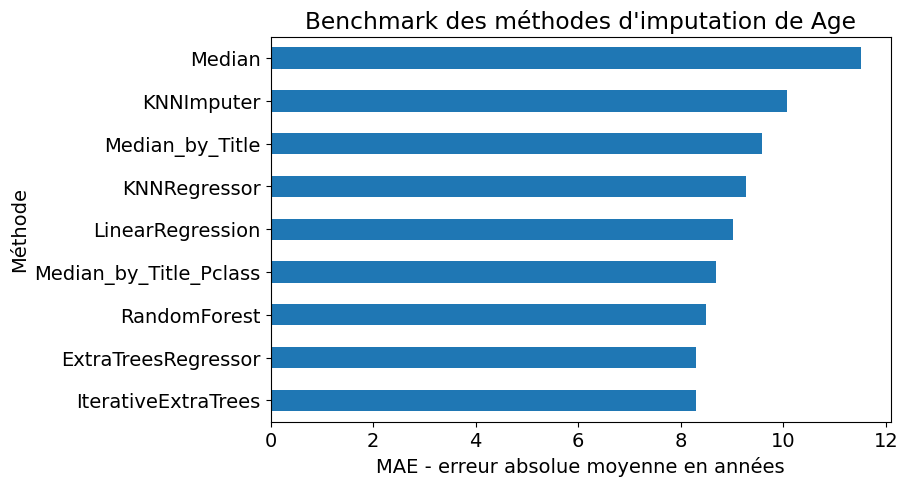

In [16]:
# visualisation simple des résultats
age_benchmark_results["MAE"].sort_values().plot(kind="barh", figsize=(8, 5))

plt.title("Benchmark des méthodes d'imputation de Age")
plt.xlabel("MAE - erreur absolue moyenne en années")
plt.ylabel("Méthode")
plt.show()

### Age - Imputation des 20% manquants

In [17]:
from titanic.imputations_age import impute_age_iterative_extra_trees

df["AgeETR"] = impute_age_iterative_extra_trees(
    df=df,
    features=age_features,
    categorical_features=categorical_features,
    age_col="Age",
    random_state=42,
    max_iter=50
)

,count,mean,std,min,25%,50%,75%,max
Age,1046.0,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0


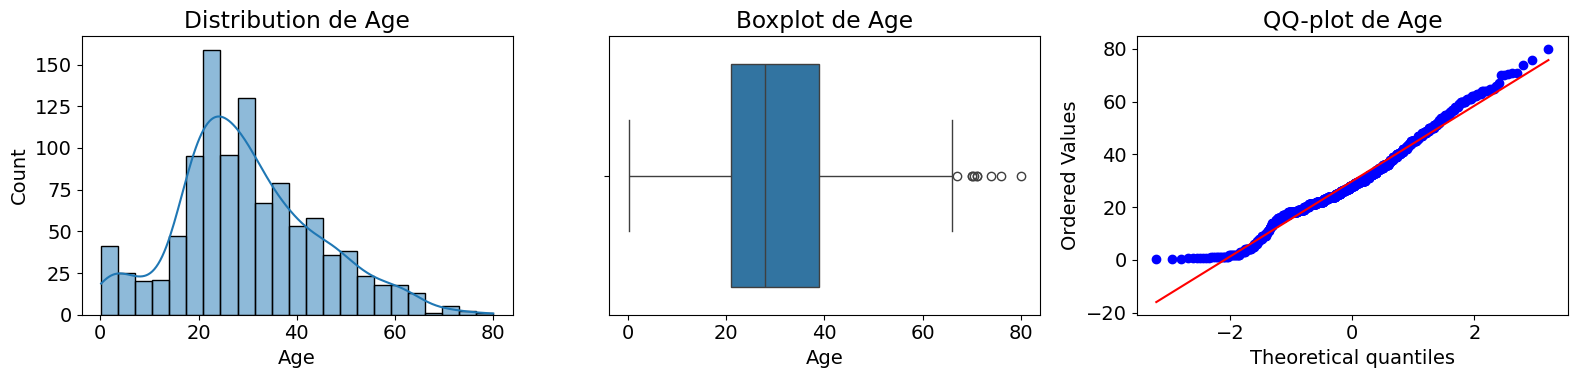

Missing values : 263
Skewness       : 0.408
Kurtosis       : 0.147


In [18]:
describe_numeric(df, "Age")

,count,mean,std,min,25%,50%,75%,max
AgeETR,1309.0,29.794378,13.457839,0.17,22.0,28.593573,37.0,80.0


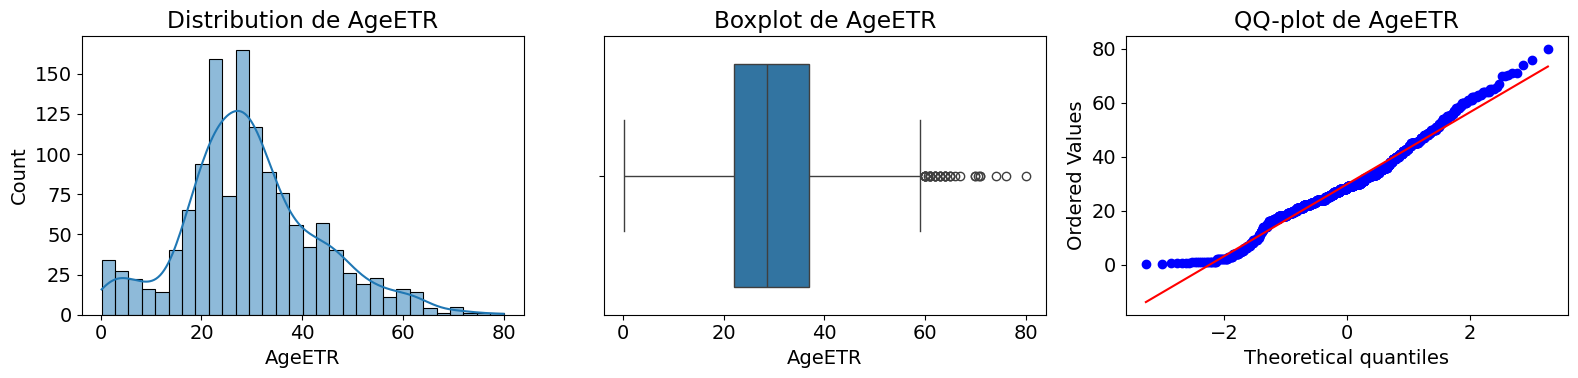

Missing values : 0
Skewness       : 0.390
Kurtosis       : 0.466


In [19]:
describe_numeric(df, "AgeETR")

### SibSp

,count,mean,std,min,25%,50%,75%,max
SibSp,1309.0,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0


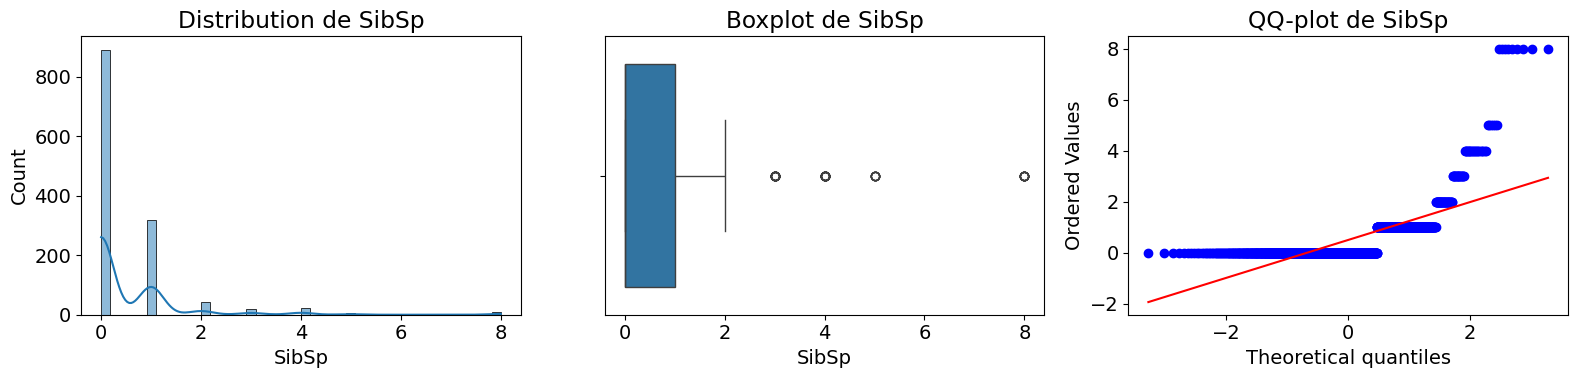

Missing values : 0
Skewness       : 3.844
Kurtosis       : 20.043


In [20]:
describe_numeric(df, "SibSp")

- La variable SibSp représente un comptage du nombre de frères, sœurs ou conjoints voyageant avec le passager.
- La distribution est fortement concentrée sur les valeurs 0 et 1, avec quelques valeurs rares plus élevées.
- Bien que la skewness et la kurtosis soient importantes, ces statistiques sont principalement dues à la nature discrète de la variable plutôt qu'à la présence d'outliers problématiques.
- Une transformation logarithmique n'apparaît pas pertinente.
- Cette variable pourra être exploitée directement ou combinée avec Parch pour construire des indicateurs de taille de famille.

### Parch

,count,mean,std,min,25%,50%,75%,max
Parch,1309.0,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0


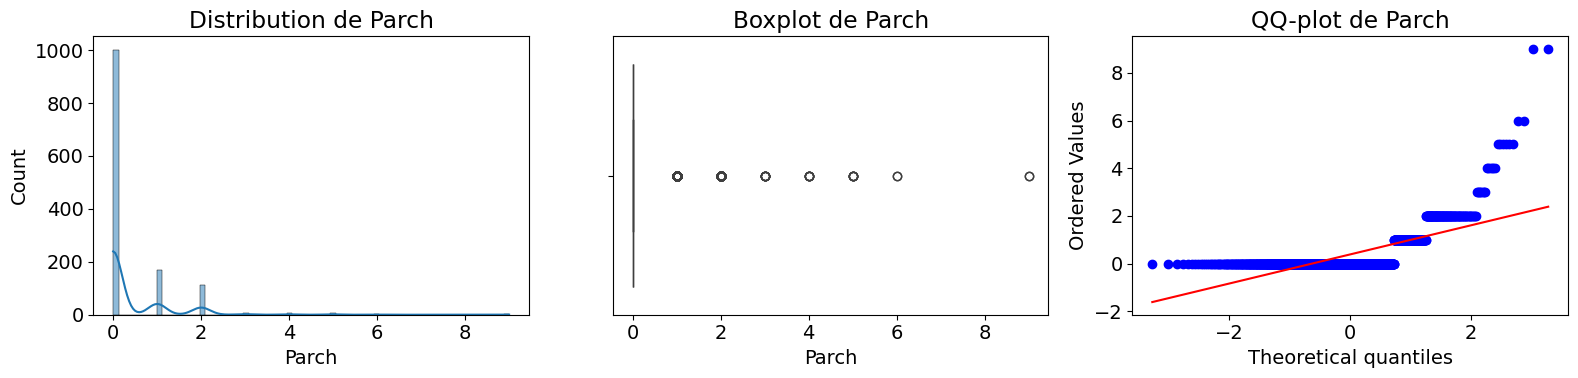

Missing values : 0
Skewness       : 3.669
Kurtosis       : 21.541


In [21]:
describe_numeric(df, "Parch")

- La variable Parch représente un comptage du nombre de parents ou enfants voyageant avec le passager.
- La distribution est similaire à celle de SibSp, avec une forte concentration sur les faibles valeurs.
- Les fortes valeurs de skewness et de kurtosis reflètent principalement le caractère discret et déséquilibré de la variable.
- Une transformation logarithmique ne semble pas justifiée.
- Une combinaison avec SibSp dans une variable de taille de famille pourra être étudiée ultérieurement.

### Ticket - Numéro du ticket

In [22]:
display(stats(df).loc[["Ticket"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/


### Fare - Prix du ticket

In [23]:
display(stats(df).loc[["Fare"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Fare,float64,1309,0 (0%),281,8.05,61,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


- 1 null qu’il faut compléter : mode ?
- 281 unique : les prix peuvent être similaire, mais vérifier qu’il n’y a pas de doublons

,count,mean,std,min,25%,50%,75%,max
Fare,1309.0,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


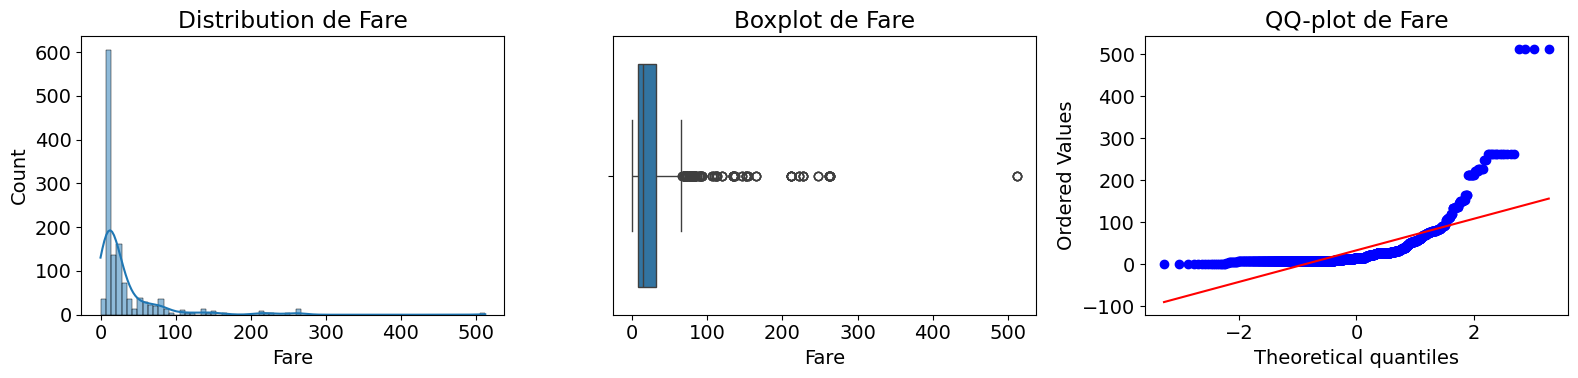

Missing values : 0
Skewness       : 4.369
Kurtosis       : 27.047


In [24]:
describe_numeric(df, "Fare")

Histogramme
- énormément de valeurs entre 0 et 30
- quelques valeurs entre 50 et 100
- très peu de valeurs > 200
- une valeur autour de 500

> La majorité des passagers paient peu cher, quelques-uns paient extrêmement cher.

Skewness (asymétrie)
- La distribution est-elle symétrique ou penche-t-elle vers un côté ?
- skewness > 0 donc queue à droite
- 4.368 = extrêmement asymétrique

Kurtosis (aplatissement / queues)
- Y a-t-il beaucoup de valeurs extrêmes ?
- kurtosis = 0
- ici, kurtosis = 27.028, donc beaucoup de valeurs extrêmes

QQ-Plot
- comparaison entre les données et une distribution normale théorique (trait rouge)


,count,mean,std,min,25%,50%,75%,max
Fare_log1p,1308.0,2.979411,0.968668,0.0,2.185579,2.737881,3.474293,6.240917


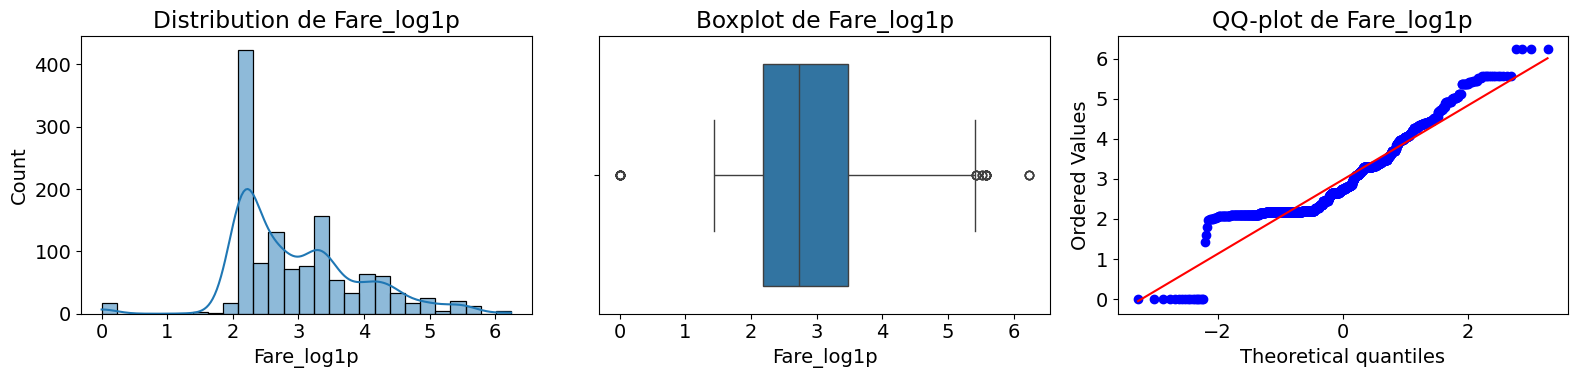

Missing values : 1
Skewness       : 0.542
Kurtosis       : 0.854


In [ ]:
# log-transform sur Fare semble intéressante

df["Fare_log1p"] = np.log1p(df["Fare"])
describe_numeric(df, "Fare_log1p")

- La variable Fare présente une forte asymétrie positive ainsi qu'une concentration importante de valeurs extrêmes.  
- Le QQ-plot confirme que la distribution s'éloigne fortement d'une loi normale.  
- Une transformation logarithmique log1p(Fare) réduit significativement l'asymétrie (4.37 → 0.54) et la kurtosis (27.03 → 0.85), produisant une distribution plus régulière.

> Cette transformation sera considérée lors de l'étape de feature engineering.  
> Il semble que certains ticket soient en doublons (929 uniques / 1309) donc certains tickets doivent renseigné plusieurs personnes : à normaliser

In [ ]:
from titanic.features import compute_fare_by_ticket, count_values

df["TicketValueCounts"] = count_values(df, "Ticket")
df["FareByTicket"] = compute_fare_by_ticket(df)
df["FareByTicket_log1p"] = np.log1p(df["FareByTicket"])

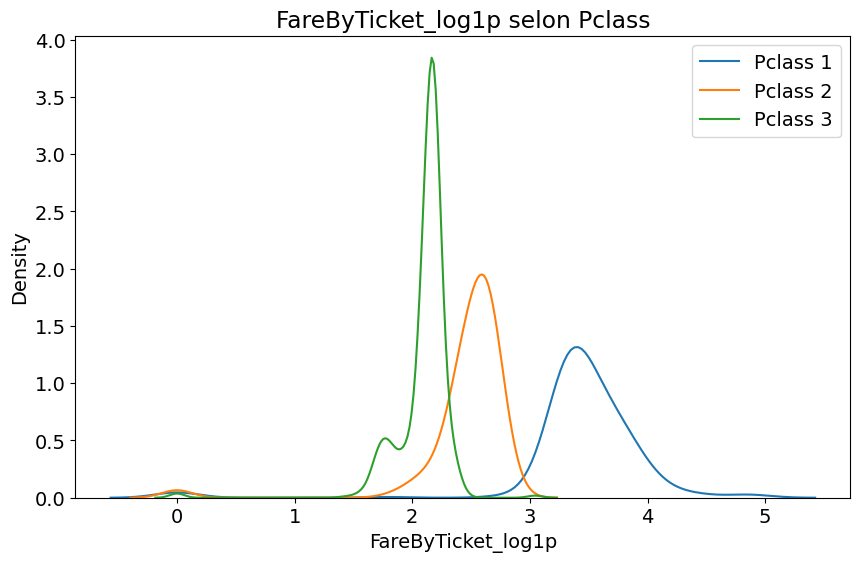

In [ ]:
plt.figure(figsize=(10,6))

for pclass in sorted(df["Pclass"].unique()):
    sns.kdeplot(
        data=df[df["Pclass"] == pclass],
        x="FareByTicket_log1p",
        label=f"Pclass {pclass}",
        fill=False
    )

plt.legend()
plt.title("FareByTicket_log1p selon Pclass")
plt.show()

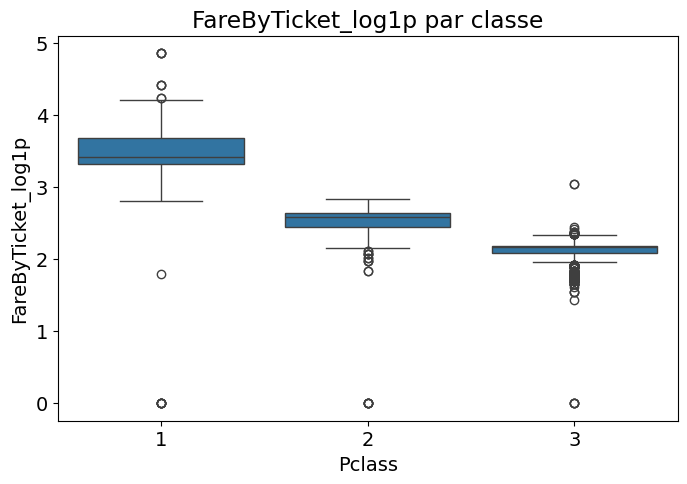

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Pclass",
    y="FareByTicket_log1p"
)

plt.title("FareByTicket_log1p par classe")
plt.show()

In [ ]:
# valeur null de Fare

df[df["Fare"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Fare_log1p,TicketValueCounts,FareByTicket,FareByTicket_log1p
1043,1044,NaN,3,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,NaN,1,NaN,NaN


In [ ]:
train.groupby("Pclass")["Fare"].median()

Pclass
1    60.2875
2    14.2500
3     8.0500
Name: Fare, dtype: float64

In [ ]:
train.groupby(
    ["Pclass", "Embarked"]
)["Fare"].median()

Pclass  Embarked
1       C           78.2667
        Q           90.0000
        S           52.0000
2       C           24.0000
        Q           12.3500
        S           13.5000
3       C            7.8958
        Q            7.7500
        S            8.0500
Name: Fare, dtype: float64

<Axes: xlabel='Pclass', ylabel='Fare'>

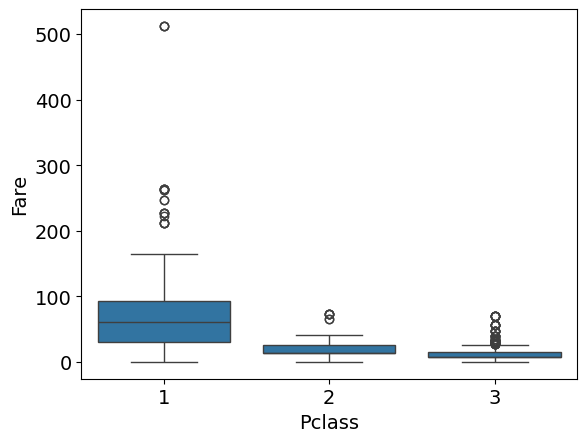

In [ ]:
sns.boxplot(
    data=train,
    x="Pclass",
    y="Fare"
)

<Axes: xlabel='Embarked', ylabel='Fare'>

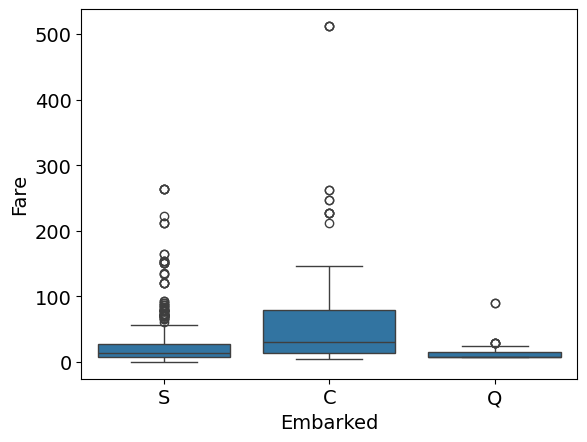

In [ ]:
sns.boxplot(
    data=train,
    x="Embarked",
    y="Fare"
)

### HasCabin

In [25]:
display(stats(df).loc[["Cabin"]])

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
Cabin,str,295,1014 (78%),186,C23 C25 C27,6,/,/,/,/,/,/,/


In [26]:
df["HasCabin"] = df["Cabin"].notna().astype(int)

In [28]:
df["HasCabin"].value_counts()

HasCabin
0    1014
1     295
Name: count, dtype: int64

## Dataset overview

In [39]:
stats(df)

,type,count,null,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,int64,1309,0 (0%),1309,1,1,655.0,378.020061,1.0,328.0,655.0,982.0,1309.0
Survived,float64,891,418 (32%),2,0.0,549,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,int64,1309,0 (0%),3,3,709,2.294882,0.837836,1.0,2.0,3.0,3.0,3.0
Name,str,1309,0 (0%),1307,"Connolly, Miss. Kate",2,/,/,/,/,/,/,/
Sex,str,1309,0 (0%),2,male,843,/,/,/,/,/,/,/
Age,float64,1046,263 (21%),98,24.0,47,29.881138,14.413493,0.17,21.0,28.0,39.0,80.0
SibSp,int64,1309,0 (0%),7,0,891,0.498854,1.041658,0.0,0.0,0.0,1.0,8.0
Parch,int64,1309,0 (0%),8,0,1002,0.385027,0.86556,0.0,0.0,0.0,0.0,9.0
Ticket,str,1309,0 (0%),929,CA. 2343,11,/,/,/,/,/,/,/
Fare,float64,1309,0 (0%),281,8.05,61,33.276193,51.743584,0.0,7.8958,14.4542,31.275,512.3292


## Data export

In [4]:
df.to_csv("../data/processed/titanic.csv", index=False)